In [112]:
import numpy as np
import matplotlib.pyplot as plt

# Código: Series de Fourier 

## Autovectores de la matriz Laplaciana


Definición de la matriz Laplaciana a partir de un grafo:

$$
L = D - A
$$

Con $D$ la matriz diagonal de grados y $A$ la matriz de adyacencia.

Para un camino de longitud $n$

<div style="text-align: center;">
<svg xmlns="http://www.w3.org/2000/svg" width="400" height="80" viewBox="0.00 0.00 230.00 1.00" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink">
<g id="graph0" class="graph" transform="scale(1 1) rotate(0) translate(4 11)">
<title>G</title>
<polygon fill="white" stroke="transparent" points="-4,4 -4,-11 226,-11 226,4 -4,4"/>
<!-- a -->
<g id="node1" class="node">
<title>a</title>
<ellipse fill="none" stroke="black" cx="3.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- b -->
<g id="node2" class="node">
<title>b</title>
<ellipse fill="none" stroke="black" cx="46.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- a&#45;&gt;b -->
<g id="edge1" class="edge">
<title>a&#45;&gt;b</title>
<path fill="none" stroke="black" d="M7.19,-3.5C14.6,-3.5 35.26,-3.5 42.75,-3.5"/>
</g>
<!-- c -->
<g id="node3" class="node">
<title>c</title>
<ellipse fill="none" stroke="black" cx="89.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- b&#45;&gt;c -->
<g id="edge2" class="edge">
<title>b&#45;&gt;c</title>
<path fill="none" stroke="black" d="M50.19,-3.5C57.6,-3.5 78.26,-3.5 85.75,-3.5"/>
</g>
<!-- d -->
<g id="node4" class="node">
<title>d</title>
<ellipse fill="none" stroke="black" cx="132.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- c&#45;&gt;d -->
<g id="edge3" class="edge">
<title>c&#45;&gt;d</title>
<path fill="none" stroke="black" d="M93.19,-3.5C100.6,-3.5 121.26,-3.5 128.75,-3.5"/>
</g>
<!-- e -->
<g id="node5" class="node">
<title>e</title>
<ellipse fill="none" stroke="black" cx="175.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- d&#45;&gt;e -->
<g id="edge4" class="edge">
<title>d&#45;&gt;e</title>
<path fill="none" stroke="black" d="M136.19,-3.5C143.6,-3.5 164.26,-3.5 171.75,-3.5"/>
</g>
<!-- f -->
<g id="node6" class="node">
<title>f</title>
<ellipse fill="none" stroke="black" cx="218.5" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- e&#45;&gt;f -->
<g id="edge5" class="edge">
<title>e&#45;&gt;f</title>
<path fill="none" stroke="black" d="M179.19,-3.5C186.6,-3.5 207.26,-3.5 214.75,-3.5"/>
</g>
</g>
</svg>
</div>



$$
\begin{align*}
\mathbf{L} &= \begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
\vdots & \ddots & \ddots & \ddots & \vdots \\
0 & \cdots & -1 & 2 & -1 \\
0 & \cdots & 0 & -1 & 2 \\
\end{bmatrix}
\end{align*}
$$


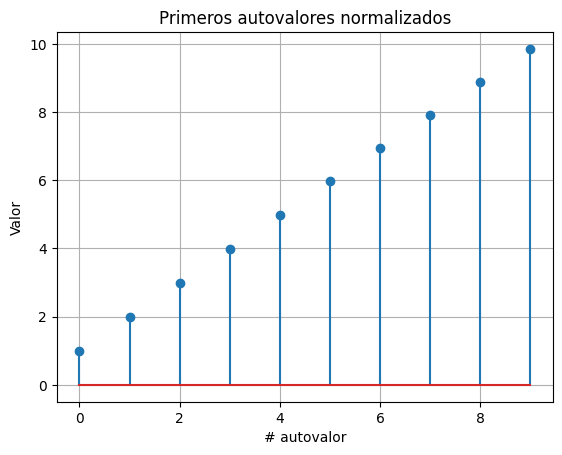

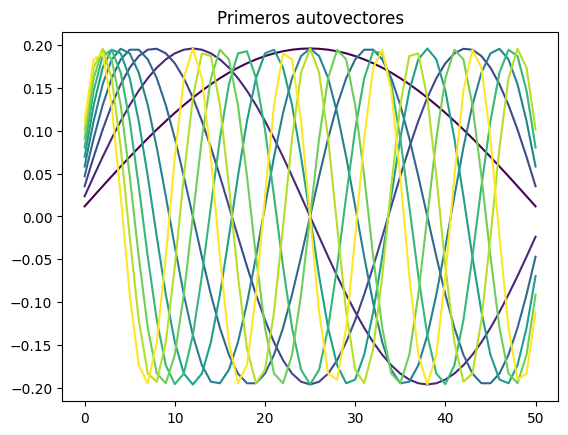

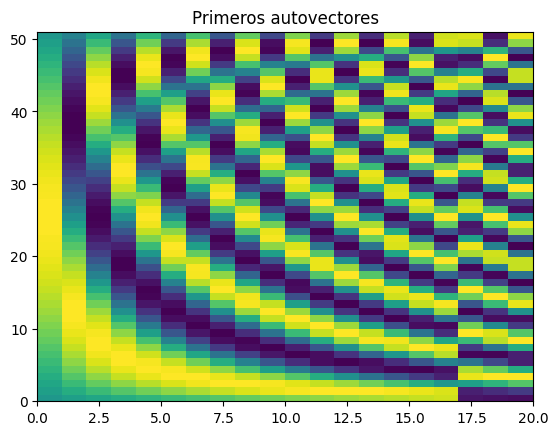

In [113]:
def laplacian_matrix(n):
    """
    Crea una matriz Laplaciana para una cuadrícula 1D de tamaño n.    
    """
    L = -np.diag(np.ones(n-1), -1) - np.diag(np.ones(n-1), 1) + np.diag(np.ones(n))*2
    return L

n = 51
r = np.linalg.eigh(laplacian_matrix(n))
w = np.sqrt(r.eigenvalues)
D = r.eigenvectors
D = D*np.sign(np.diff(D,axis=0)[0,:])

k = 10
plt.stem(w[:k]/w[0])
plt.grid()
plt.title("Primeros autovalores normalizados")
plt.ylabel("Valor")
plt.xlabel("# autovalor")
plt.figure()
# color cycle viridis
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.viridis(np.linspace(0,1, k))))
plt.plot(D[:,:k])
plt.title("Primeros autovectores")

plt.figure()
plt.pcolor(D[:,:k*2], cmap=plt.cm.viridis)
plt.title("Primeros autovectores")
plt.show()

Analicemos una curva triangular con esta base

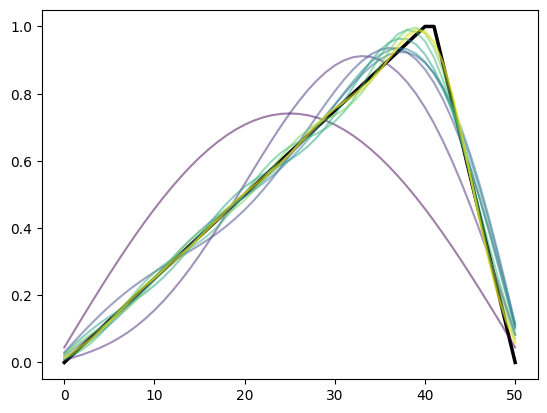

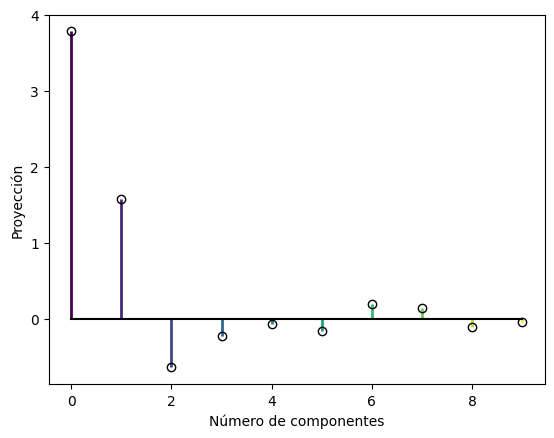

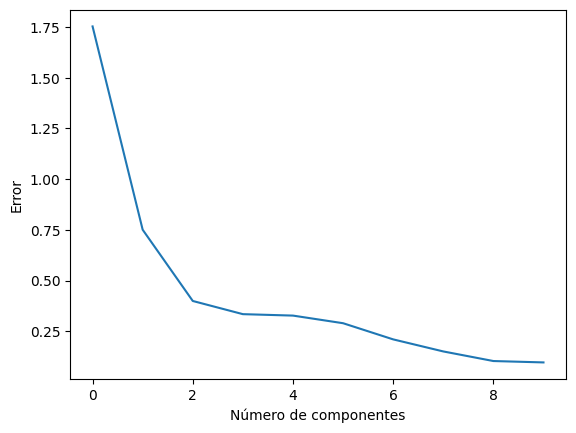

In [114]:
## Triangulo con vertice en d
d = 10
x = np.r_[np.linspace(0, 1, n-d), np.linspace(1, 0, d)]

k = 10
D = r.eigenvectors[:,:k]
y = x @ D
z = np.cumsum(y*D,1)

plt.figure()
plt.plot(x,linewidth=2.5, color='k');
# set color gradient cycle
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.viridis(np.linspace(0, 1, k))))
plt.plot(z, alpha=0.5);

plt.figure()
# different color each stem
ml,sl,_ = plt.stem(y, linefmt='k', basefmt='k', markerfmt='ko')
ml.set_markerfacecolor('none')
sl.set_colors(plt.cm.viridis(np.linspace(0, 1, k)))
sl.set_linewidth(2)

plt.xlabel("Número de componentes")
plt.ylabel("Proyección");

# plot de convergencia
plt.figure()
plt.plot(np.linalg.norm(z.T-x,axis=1));
plt.xlabel("Número de componentes")
plt.ylabel("Error");

Si realizamos el mismo procedimiento para un grafo cíclico de longitud $n$ obtenemos una matriz similar cuyos autovectores ahora son senos y cosenos.


<div style="text-align: center;">

<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"
 "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">
<!-- Generated by graphviz version 2.43.0 (0)
 -->
<!-- Title: G Pages: 1 -->
<svg width="266" height="254" viewBox="0.00 0.00 266.46 254.16" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink">
<g id="graph0" class="graph" transform="scale(1 1) rotate(0) translate(4 250.16)">
<title>G</title>
<polygon fill="white" stroke="transparent" points="-4,4 -4,-250.16 262.46,-250.16 262.46,4 -4,4"/>
<!-- a -->
<g id="node1" class="node">
<title>a</title>
<ellipse fill="none" stroke="black" cx="230.95" cy="-49.17" rx="3.5" ry="3.5"/>
</g>
<!-- b -->
<g id="node2" class="node">
<title>b</title>
<ellipse fill="none" stroke="black" cx="168.09" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- a&#45;&gt;b -->
<g id="edge1" class="edge">
<title>a&#45;&gt;b</title>
<path fill="none" stroke="black" d="M227.92,-46.97C217.23,-39.2 181.36,-13.14 170.94,-5.58"/>
</g>
<!-- c -->
<g id="node3" class="node">
<title>c</title>
<ellipse fill="none" stroke="black" cx="90.38" cy="-3.5" rx="3.5" ry="3.5"/>
</g>
<!-- b&#45;&gt;c -->
<g id="edge2" class="edge">
<title>b&#45;&gt;c</title>
<path fill="none" stroke="black" d="M164.34,-3.5C151.12,-3.5 106.78,-3.5 93.91,-3.5"/>
</g>
<!-- d -->
<g id="node4" class="node">
<title>d</title>
<ellipse fill="none" stroke="black" cx="27.51" cy="-49.17" rx="3.5" ry="3.5"/>
</g>
<!-- c&#45;&gt;d -->
<g id="edge3" class="edge">
<title>c&#45;&gt;d</title>
<path fill="none" stroke="black" d="M87.35,-5.7C76.65,-13.47 40.78,-39.53 30.37,-47.1"/>
</g>
<!-- e -->
<g id="node5" class="node">
<title>e</title>
<ellipse fill="none" stroke="black" cx="3.5" cy="-123.08" rx="3.5" ry="3.5"/>
</g>
<!-- d&#45;&gt;e -->
<g id="edge4" class="edge">
<title>d&#45;&gt;e</title>
<path fill="none" stroke="black" d="M26.35,-52.74C22.27,-65.31 8.57,-107.48 4.59,-119.72"/>
</g>
<!-- f -->
<g id="node6" class="node">
<title>f</title>
<ellipse fill="none" stroke="black" cx="27.51" cy="-196.98" rx="3.5" ry="3.5"/>
</g>
<!-- e&#45;&gt;f -->
<g id="edge5" class="edge">
<title>e&#45;&gt;f</title>
<path fill="none" stroke="black" d="M4.66,-126.64C8.74,-139.21 22.44,-181.38 26.42,-193.62"/>
</g>
<!-- g -->
<g id="node7" class="node">
<title>g</title>
<ellipse fill="none" stroke="black" cx="90.38" cy="-242.66" rx="3.5" ry="3.5"/>
</g>
<!-- f&#45;&gt;g -->
<g id="edge6" class="edge">
<title>f&#45;&gt;g</title>
<path fill="none" stroke="black" d="M30.54,-199.19C41.24,-206.95 77.11,-233.02 87.52,-240.58"/>
</g>
<!-- h -->
<g id="node8" class="node">
<title>h</title>
<ellipse fill="none" stroke="black" cx="168.09" cy="-242.66" rx="3.5" ry="3.5"/>
</g>
<!-- g&#45;&gt;h -->
<g id="edge7" class="edge">
<title>g&#45;&gt;h</title>
<path fill="none" stroke="black" d="M94.13,-242.66C107.35,-242.66 151.68,-242.66 164.55,-242.66"/>
</g>
<!-- i -->
<g id="node9" class="node">
<title>i</title>
<ellipse fill="none" stroke="black" cx="230.95" cy="-196.98" rx="3.5" ry="3.5"/>
</g>
<!-- h&#45;&gt;i -->
<g id="edge8" class="edge">
<title>h&#45;&gt;i</title>
<path fill="none" stroke="black" d="M171.12,-240.45C181.81,-232.68 217.68,-206.62 228.1,-199.06"/>
</g>
<!-- j -->
<g id="node10" class="node">
<title>j</title>
<ellipse fill="none" stroke="black" cx="254.96" cy="-123.08" rx="3.5" ry="3.5"/>
</g>
<!-- i&#45;&gt;j -->
<g id="edge9" class="edge">
<title>i&#45;&gt;j</title>
<path fill="none" stroke="black" d="M232.11,-193.42C236.19,-180.85 249.9,-138.68 253.87,-126.44"/>
</g>
<!-- j&#45;&gt;a -->
<g id="edge10" class="edge">
<title>j&#45;&gt;a</title>
<path fill="none" stroke="black" d="M253.81,-119.51C249.72,-106.94 236.02,-64.77 232.04,-52.53"/>
</g>
</g>
</svg>

</div>


Norma de los autovectores todos 1 True


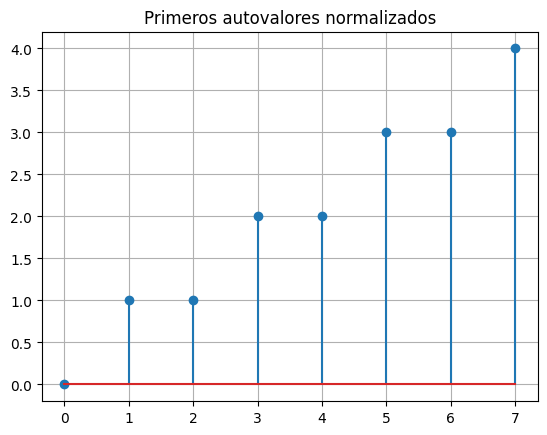

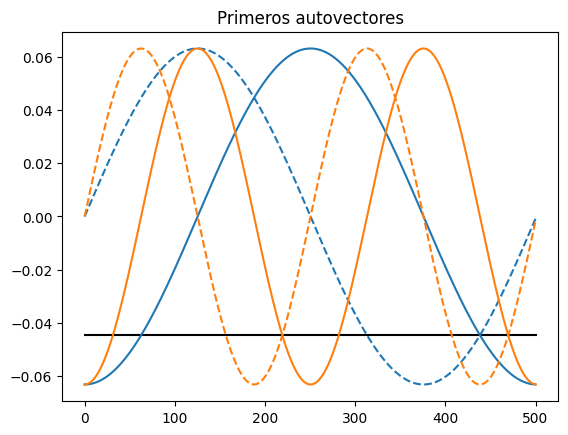

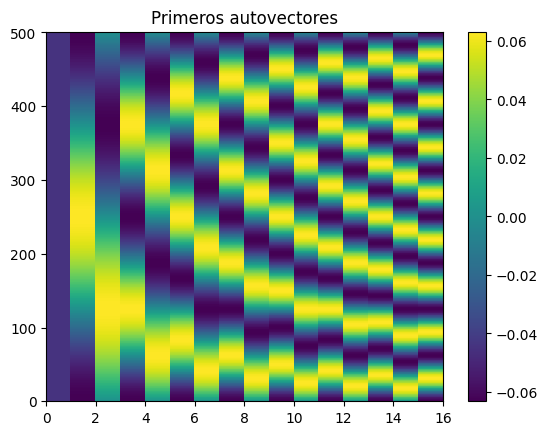

In [115]:
# laplacian with cyclic condition
def laplacian_matrix_cyclic(n):
    """
    Crea una matriz Laplaciana para una cuadrícula 1D de tamaño n con condiciones cíclicas.
    """
    L = -np.diag(np.ones(n-1), -1) - np.diag(np.ones(n-1), 1) + np.diag(np.ones(n))*2
    L[0, -1] = -1
    L[-1, 0] = -1
    return L

n = 501
r = np.linalg.eigh(laplacian_matrix_cyclic(n))
D = r.eigenvectors
D = D*np.sign(np.diff(D,axis=0)[0,:])

w = np.sqrt(np.abs(r.eigenvalues*n))
argix = np.argsort(w)
w = w[argix]
k = 8

plt.figure()
plt.stem(w[:k]/w[1])
plt.grid()
plt.title("Primeros autovalores normalizados")
plt.figure()
# style cycle alternate - and --
plt.gca().set_prop_cycle(plt.cycler('linestyle', ['-']+['-', '--']*10) +
                         plt.cycler('color',np.r_[[[0,0,0,1]],plt.cm.tab10(np.repeat(np.arange(10), 2))]))
plt.plot(D[:,:5])
plt.title("Primeros autovectores")
plt.figure()
plt.pcolor(D[:,:k*2])
plt.colorbar()
plt.title("Primeros autovectores")

print("Norma de los autovectores todos 1", np.allclose(np.linalg.norm(D,axis=0),1))

Ahora podemos proyectar curvas que no tengan los extremos fijos.

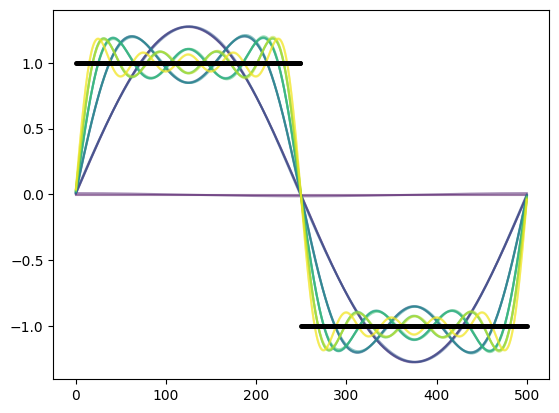

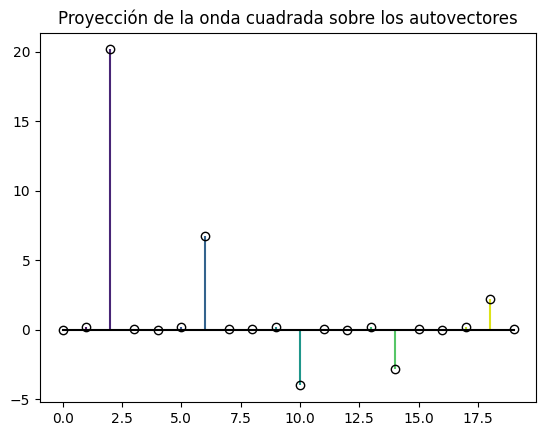

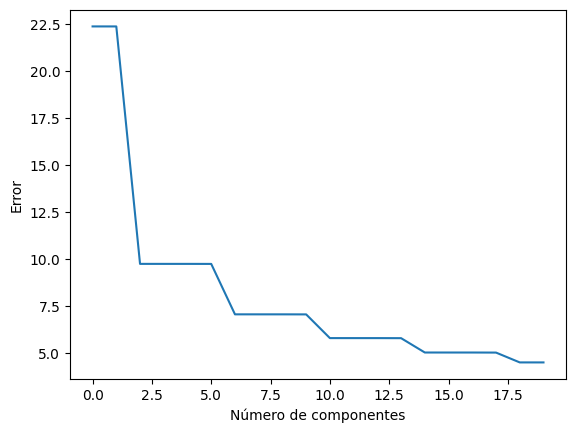

In [116]:
# Dibuja una onda cuadrada un ciclo 
x = np.zeros(n)
x[0:n//2] = 1
x[n//2:] = -1

# Proyecta sobre los autovectores
D = r.eigenvectors
y = x @ D

k = 20
z = np.cumsum(y[:k]*D[:,:k],1)

plt.figure()
plt.plot(x, ".", color='k', zorder=10, markersize=5);
# set color gradient cycle
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.viridis(np.linspace(0, 1, k))))
plt.plot(z, alpha=0.5);


plt.figure()
# different color each stem
ml,sl,_ = plt.stem(y[:k], linefmt='k', basefmt='k', markerfmt='ko')
ml.set_markerfacecolor('none')
sl.set_colors(plt.cm.viridis(np.linspace(0, 1, k)))
plt.title("Proyección de la onda cuadrada sobre los autovectores")


plt.figure()
plt.plot(np.linalg.norm(z.T-x,axis=1))
plt.ylabel("Error");
plt.xlabel("Número de componentes");

## Base de senos y cosenos

Repetimos el procedimiento, pero construyendo una matriz explicitamente con senos y cosenos. Para no depender del calculo de autovectores.

Norma de los autovectores todos 1 False


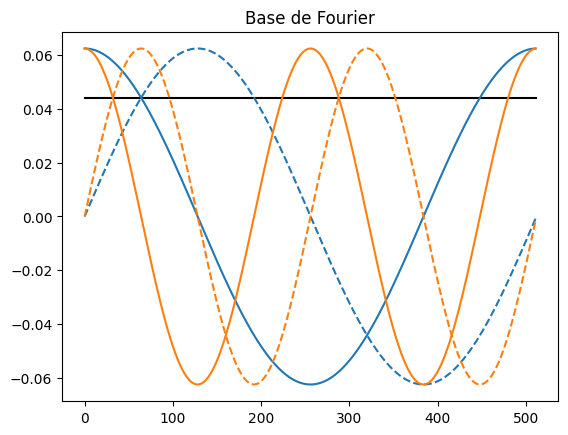

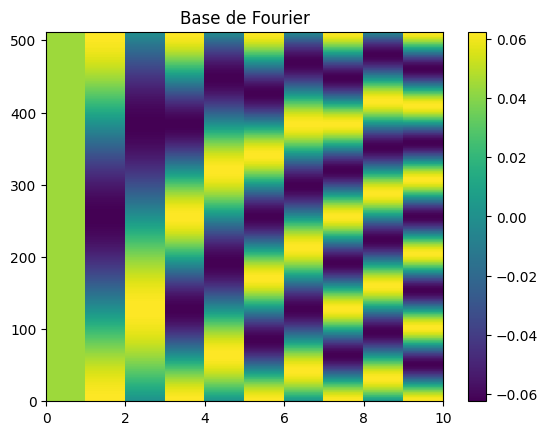

In [117]:
def generar_base_fourier(n, armonicos):
    """
    Generar una base de Fourier con senos y cosenos
    
    Parámetros:Parámetros:
        n: Número de puntos de muestra
        armonicos: Número de armónicos a incluir
    
    Retorna:
        F: Matriz donde las columnas son las funciones base de Fourier
    """
    # Crear puntos de muestra en [0, 2π)rear puntos de muestra en [0, 2π)
    x = np.linspace(0, 2*np.pi, n, endpoint=False)
    
    # Inicializar la matriz base de Fourier# Inicializar la matriz base de Fourier
    F = np.ones((n, 1 + 2*armonicos))
    
    # Primera columna es el término constante (componente DC)# Primera columna es el término constante (componente DC)
    F[:, 0] = 1.0 / np.sqrt(n)
    
    # Llenar el resto con senos y cosenos# Llenar el resto con senos y cosenos
    for k in range(1, armonicos + 1):
        # Base de coseno (normalizada))
        F[:, 2*k-1] = np.sqrt(2/n) * np.cos(k * x)
        # Base de seno (normalizada)
        F[:, 2*k] = np.sqrt(2/n) * np.sin(k * x)
        
    return F

# Generar la base de Fourier
n = 512
k = 256
F = generar_base_fourier(n, k)
plt.figure()
plt.gca().set_prop_cycle(plt.cycler('linestyle', ['-']+['-', '--']*10) +
                         plt.cycler('color',np.r_[[[0,0,0,1]],plt.cm.tab10(np.repeat(np.arange(10), 2))]))
plt.plot(F[:, :5])
plt.title("Base de Fourier")
plt.figure()
plt.pcolor(F[:, :10])
plt.colorbar()
plt.title("Base de Fourier");

print("Norma de los autovectores todos 1", np.allclose(np.linalg.norm(F,axis=0),1))

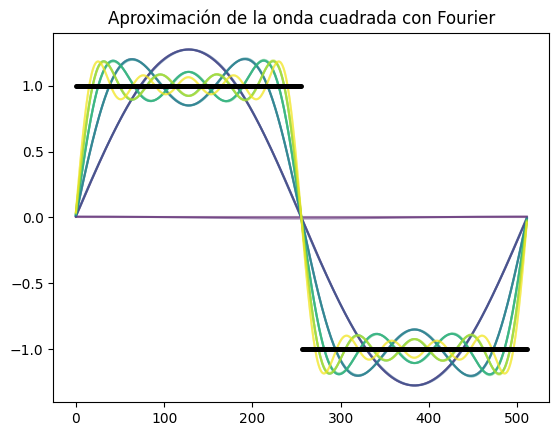

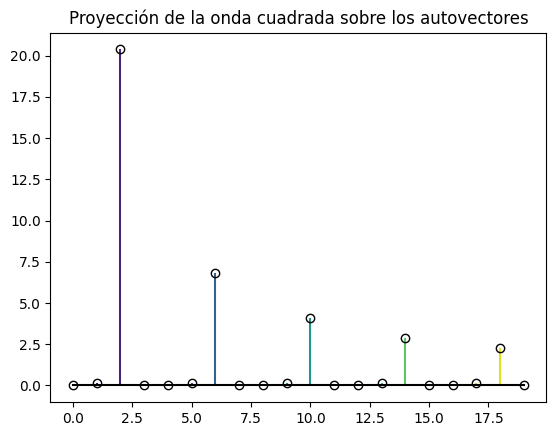

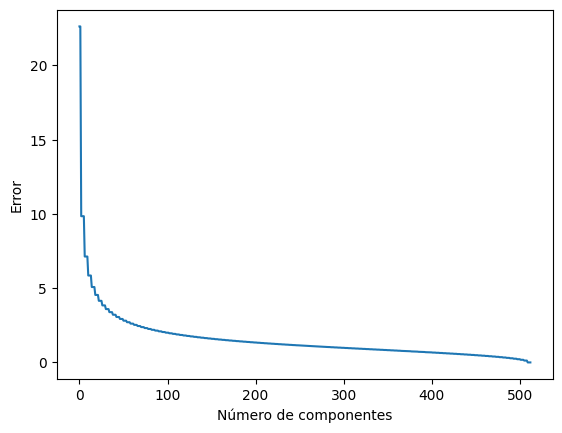

In [118]:
x = np.zeros(n)
x[0:n//2] = 1
x[n//2:] = -1

# Proyecta sobre los autovectores
y = x @ F
k = 20
z = np.cumsum(y[:k]*F[:,:k],1)

plt.figure()
plt.plot(x, ".", color='k', zorder=10, markersize=5);
# set color gradient cycle
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.viridis(np.linspace(0, 1, k))))
plt.plot(z, alpha=0.5);
plt.title("Aproximación de la onda cuadrada con Fourier");


plt.figure()
ml, sl,_ = plt.stem(y[:k], linefmt='k', basefmt='k', markerfmt='ko')
ml.set_markerfacecolor('none')
sl.set_colors(plt.cm.viridis(np.linspace(0, 1, k)))
plt.title("Proyección de la onda cuadrada sobre los autovectores");

z = np.cumsum(y*F,1)
plt.figure()
plt.plot(np.linalg.norm(z.T-x,axis=1))
plt.ylabel("Error")
plt.xlabel("Número de componentes");

## Exponenciales Complejas

Repetimos el procedimiento, pero construyendo una matriz explicitamente con exponenciales complejas para poder visualizar facilmente la magnitud y fase de las componentes.

Norma de los autovectores todos 1 True


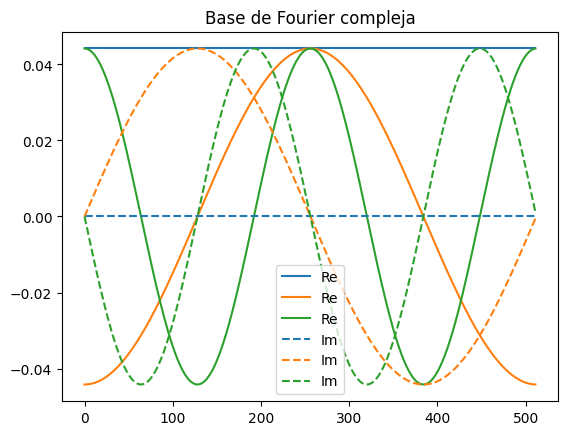

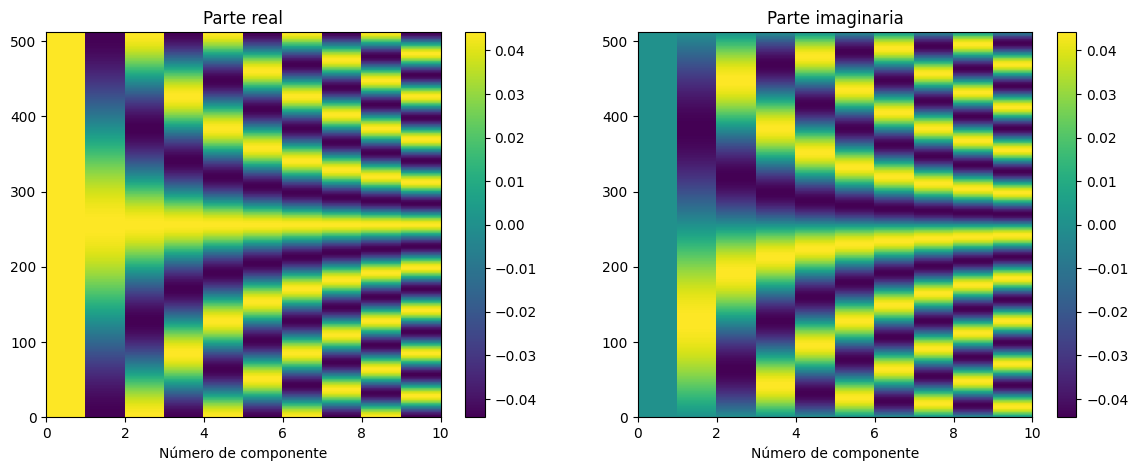

In [119]:
def base_de_fourier_compleja(n, armonicos):
    """
    Generar una base de Fourier compleja
    
    Parámetros:
        n: Número de puntos de muestra
        armonicos: Número de armónicos a incluir
    
    Retorna:
        F: Matriz donde las columnas son las funciones base de Fourier complejas
    """
    # Crear puntos de muestra en [-π, π)
    x = np.linspace(0, 2*np.pi, n, endpoint=False)-np.pi
    
    # Inicializar la matriz base de Fourier compleja
    F = np.zeros((n, 1 + armonicos), dtype=complex)
    
    # Llenar la matriz con exponentes complejos
    for k in range(0, armonicos + 1):
        F[:, k] = np.exp(-1j * k * x) / np.sqrt(n)
        
    return F
# Generar la base de Fourier compleja
n = 512
k = 256
F = base_de_fourier_compleja(n, k)
plt.figure()
p = 3
plt.gca().set_prop_cycle(plt.cycler('linestyle', ['-']*p+['--']*p
                                    ) +
                         plt.cycler('color',plt.cm.tab10(np.tile(np.arange(p),2))))
plt.plot(F[:, :p].real, label="Re")
plt.plot(F[:, :p].imag, label="Im")
plt.legend()

plt.title("Base de Fourier compleja")
plt.figure(figsize=(14,5))
plt.subplot(121)
plt.pcolor(F[:, :10].real)
plt.xlabel("Número de componente")
plt.title("Parte real")
plt.colorbar()
plt.subplot(122)
plt.pcolor(F[:, :10].imag)
plt.title("Parte imaginaria")
plt.xlabel("Número de componente")
plt.colorbar();

print("Norma de los autovectores todos 1", np.allclose(np.linalg.norm(F,axis=0),1))

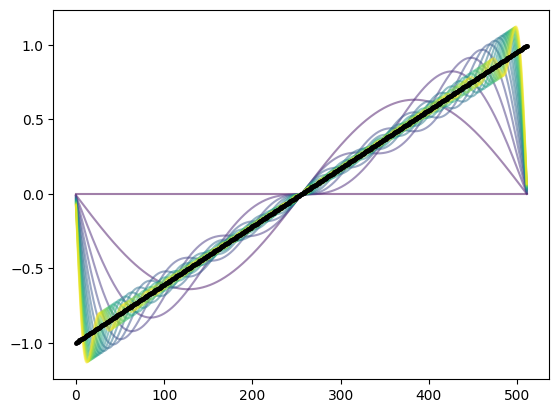

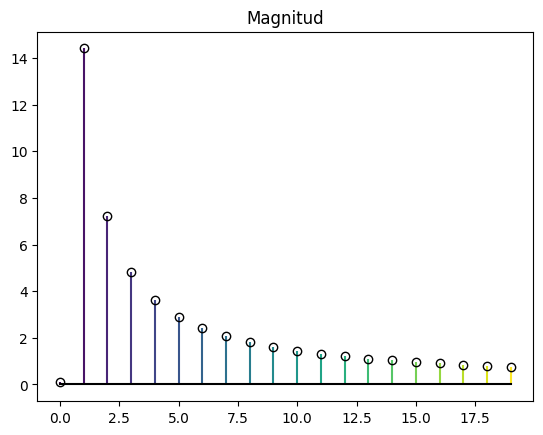

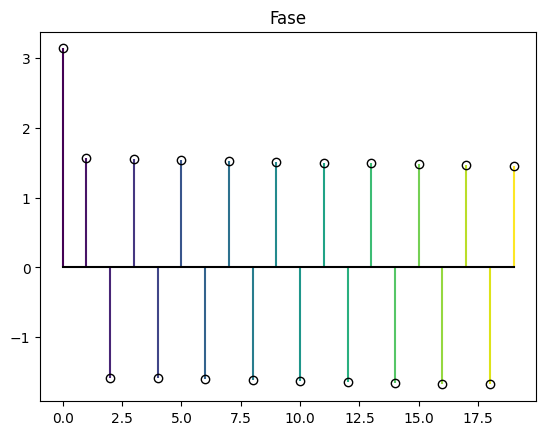

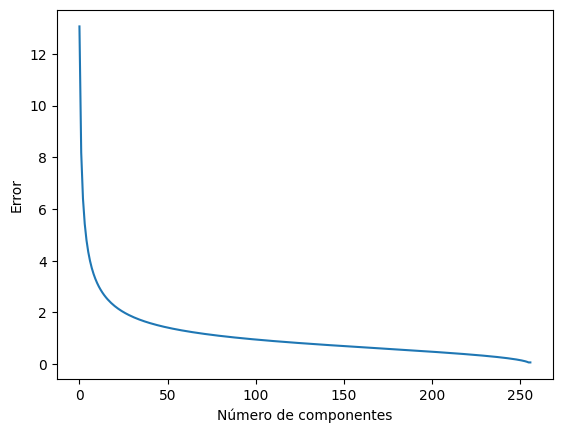

In [120]:
# Dientes de sierra
x = np.linspace(-1, 1, n, endpoint=False)
y = x @ F.conj() * 2
k = 20
z = np.cumsum(y[:k]*F[:,:k],1).real

plt.figure()
plt.plot(x, ".", color='k', zorder=10, markersize=5);
# set color gradient cycle
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.viridis(np.linspace(0, 1, k))))
plt.plot(z, alpha=0.5);

plt.figure()
ml, sl,_ = plt.stem(np.abs(y[:k]), linefmt='k', basefmt='k', markerfmt='ko')
ml.set_markerfacecolor('none')
sl.set_colors(plt.cm.viridis(np.linspace(0, 1, k)))
plt.title("Magnitud");

plt.figure()
ml, sl,_ = plt.stem(np.angle(y[:k]), linefmt='k', basefmt='k', markerfmt='ko')
ml.set_markerfacecolor('none')
sl.set_colors(plt.cm.viridis(np.linspace(0, 1, k)))
plt.title("Fase");

z = np.cumsum(y*F,1).real
plt.figure()
plt.plot(np.linalg.norm(z.T-x,axis=1))
plt.xlabel("Número de componentes")
plt.ylabel("Error");